In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH  = Path(r"C:\Users\USER\Desktop\kasheftest\Git_hub\Kashef_anomaly_detection\data\process\KJ_finalData_102.csv")
CP_PATH    = Path(r"C:\Users\USER\Desktop\kasheftest\Git_hub\Kashef_anomaly_detection\src\test\simple_changepoint\change_points.csv")
OUTPUT_DIR = Path(r"src\test\changepoint_EI")

RSSI_COL   = "RSSI_PUCCH(EUCell_Eric)(CRA)"

# ── Load data ─────────────────────────────────────────────────────────────────
print("Loading data ...")
df = pd.read_csv(DATA_PATH, usecols=["Date", "NE", RSSI_COL, "Latitude", "Longitude"])
df["Date"] = pd.to_datetime(df["Date"])

cp = pd.read_csv(CP_PATH)
cp.columns = cp.columns.str.strip()
cp["timestamp"] = pd.to_datetime(cp["timestamp"])


Loading data ...


Sectors within 2.0 km: 117
Qualifying sectors (CP hit OR avg RSSI >= -113): 15
  — with change point in window : 3
  — with avg RSSI above threshold: 14


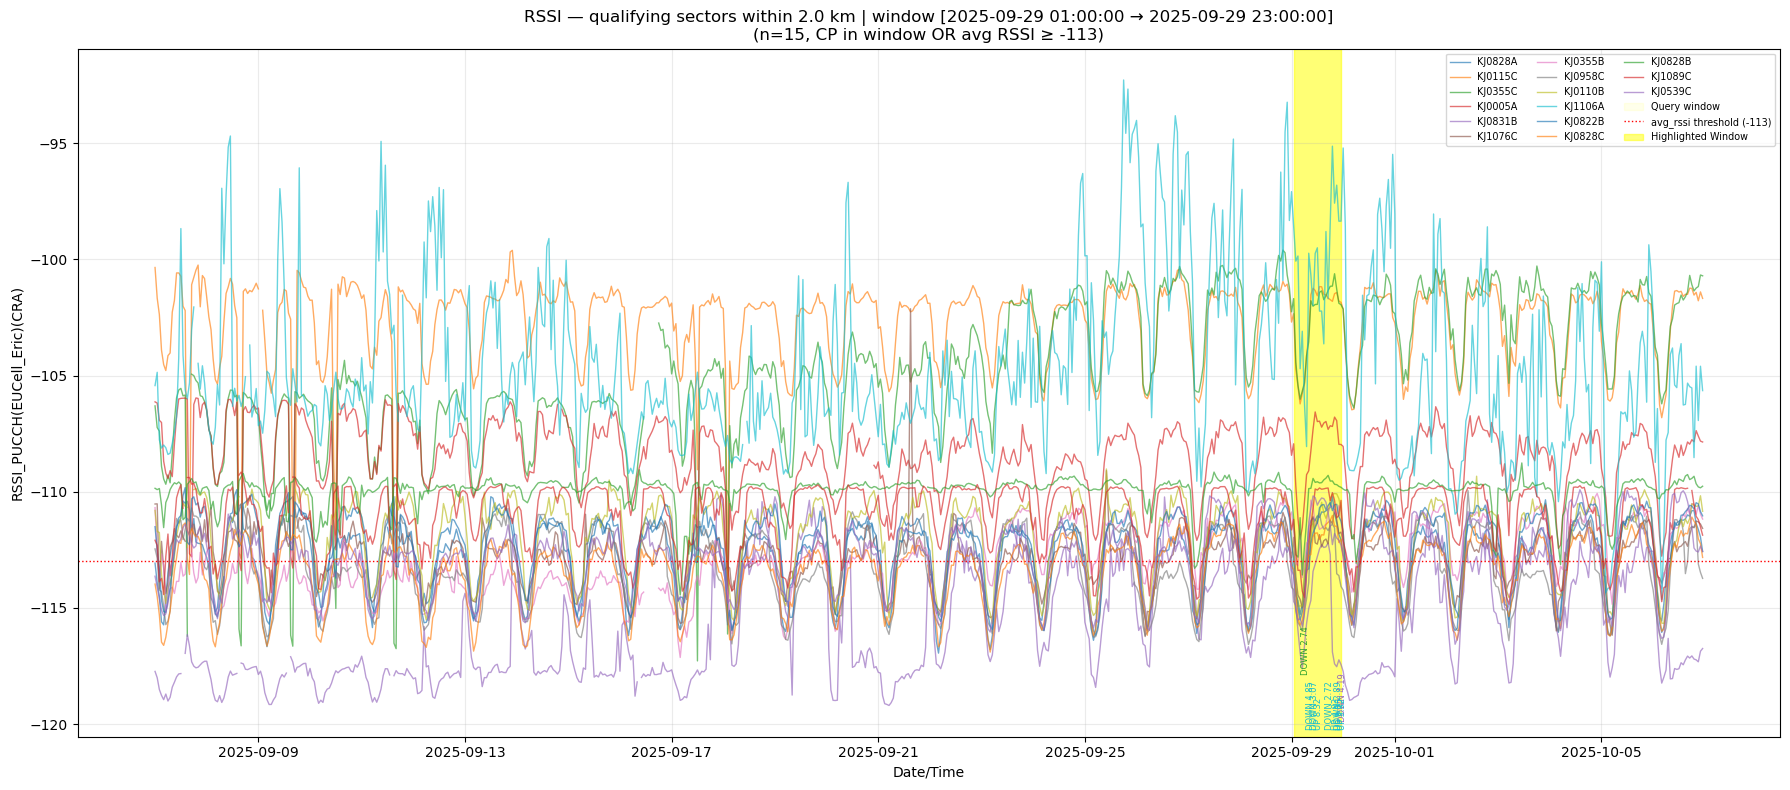

Saved 10 change points for plotted sectors to: C:\Users\USER\Desktop\kasheftest\Git_hub\Kashef_anomaly_detection\src\test\changepoint_EI_test\geo_window_change_points.csv
Saved change-point details to: C:\Users\USER\Desktop\kasheftest\Git_hub\Kashef_anomaly_detection\src\test\changepoint_EI_test\geo_window_change_points.csv
Saved sector list to: C:\Users\USER\Desktop\kasheftest\Git_hub\Kashef_anomaly_detection\src\test\changepoint_EI_test\geo_window_sectors.csv


In [8]:
# ── User inputs ──────────────────────────────────────────────────────────────
center_lat = float("35.840455")
center_lon = float("50.981873")
radius_km  = float("2")
time_start = pd.Timestamp("2025-09-29 1:00:00")
time_end   = pd.Timestamp("2025-09-29 23:00:00")
avg_rssi   = -113          # threshold: include sector if its window avg >= this value
R_EARTH_KM = 6371.0

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R_EARTH_KM * 2 * np.arcsin(np.sqrt(a))

sector_meta = df.groupby("NE").agg(Latitude=("Latitude", "first"), Longitude=("Longitude", "first"))
sector_meta["dist_km"] = haversine_km(
    center_lat, center_lon,
    sector_meta["Latitude"].values,
    sector_meta["Longitude"].values,
)
geo_sectors = sector_meta[sector_meta["dist_km"] <= radius_km].index.tolist()

if not geo_sectors:
    raise ValueError("No sectors found inside the given radius.")

print(f"Sectors within {radius_km} km: {len(geo_sectors)}")

# ── Time-window slice of main data ───────────────────────────────────────────
df_window = df[
    (df["NE"].isin(geo_sectors)) &
    (df["Date"] >= time_start) &
    (df["Date"] <= time_end)
].copy()

# ── Condition 1 – sector has at least one change point in the time window ────
cp_geo    = cp[cp["sector"].isin(geo_sectors)]
cp_window = cp_geo[
    (cp_geo["timestamp"] >= time_start) &
    (cp_geo["timestamp"] <= time_end)
]
sectors_with_cp = set(cp_window["sector"].unique())

# ── Condition 2 – sector's avg RSSI in the window is >= avg_rssi threshold ───
sector_avg = (
    df_window.groupby("NE")[RSSI_COL]
    .mean()
    .rename("avg_rssi_window")
)
sectors_above_avg = set(sector_avg[sector_avg >= avg_rssi].index.tolist())

# ── Union: sector must satisfy at least one condition ────────────────────────
qualifying_sectors = list(sectors_with_cp | sectors_above_avg)

if not qualifying_sectors:
    raise ValueError(
        "No sectors satisfy the change-point or avg-RSSI condition in the given time window."
    )

print(f"Qualifying sectors (CP hit OR avg RSSI >= {avg_rssi}): {len(qualifying_sectors)}")
print(f"  — with change point in window : {len(sectors_with_cp & set(qualifying_sectors))}")
print(f"  — with avg RSSI above threshold: {len(sectors_above_avg & set(qualifying_sectors))}")

# ── Plot ─────────────────────────────────────────────────────────────────────
# Use full time series for context, highlight the query window
df_radius = df[df["NE"].isin(qualifying_sectors)].copy()

fig, ax = plt.subplots(figsize=(18, 8))

color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, ne in enumerate(qualifying_sectors):
    color = color_cycle[i % len(color_cycle)]
    sector_df = df_radius[df_radius["NE"] == ne].sort_values("Date")

    ax.plot(
        sector_df["Date"],
        sector_df[RSSI_COL],
        label=str(ne),
        alpha=0.65,
        linewidth=1,
        color=color,
    )

    # Mark change points that fall inside the time window
    # Filter change points for this sector within the time window
    ne_cp = cp_window[
        (cp_window["sector"] == ne) &
        (cp_window["timestamp"] >= time_start) &
        (cp_window["timestamp"] <= time_end)
    ]
    
    # Additionally, restrict sector_df to the time window for plotting, if desired
    # Uncomment next two lines to only plot RSSI within the window
    # sector_df = sector_df[
    #     (sector_df["Date"] >= time_start) & (sector_df["Date"] <= time_end)
    # ]
    for _, row in ne_cp.iterrows():
        #ax.axvline(row["timestamp"], color=color, linestyle="--", linewidth=0.9, alpha=0.8)
        ax.annotate(
            f"{row['direction']} {row['magnitude']:.2f}",
            xy=(row["timestamp"], ax.get_ylim()[0]),
            xytext=(4, 6),
            textcoords="offset points",
            fontsize=6,
            color=color,
            rotation=90,
        )

# Shade the query time window
ax.axvspan(time_start, time_end, alpha=0.08, color="yellow", label="Query window")

# Threshold reference line
ax.axhline(avg_rssi, color="red", linestyle=":", linewidth=1, label=f"avg_rssi threshold ({avg_rssi})")
def highlight_time_window(ax):
    """
    Adds a vertical background span to the current axes over the interval [time_start, time_end].
    """
    ax.axvspan(time_start, time_end, color="yellow", alpha=0.5, label="Highlighted Window")

highlight_time_window(ax)

ax.set_title(
    f"RSSI — qualifying sectors within {radius_km} km | window [{time_start} → {time_end}]\n"
    f"(n={len(qualifying_sectors)}, CP in window OR avg RSSI ≥ {avg_rssi})"
)
ax.set_xlabel("Date/Time")
ax.set_ylabel(RSSI_COL)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", fontsize="x-small", ncol=3, frameon=True)
plt.tight_layout()
plt.show()

from pathlib import Path

# Ensure cp["timestamp"] is datetime
cp["timestamp"] = pd.to_datetime(cp["timestamp"])

# Filter change points for sectors that are in the plot AND in the time window
cp_export = cp[
    (cp["sector"].isin(qualifying_sectors)) &
    (cp["timestamp"] >= time_start) &
    (cp["timestamp"] <= time_end)
].copy()

# Choose output directory and filename
output_dir = Path(r"C:\Users\USER\Desktop\kasheftest\Git_hub\Kashef_anomaly_detection\src\test\changepoint_EI_test")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "geo_window_change_points.csv"
cp_export.to_csv(output_path, index=False)

print(f"Saved {len(cp_export)} change points for plotted sectors to: {output_path}")

cp_export = (
    cp_window[cp_window["sector"].isin(qualifying_sectors)]
    .sort_values(["sector", "timestamp"])
)

cp_csv_path = output_dir / "geo_window_change_points.csv"
cp_export.to_csv(cp_csv_path, index=False)
print(f"Saved change-point details to: {cp_csv_path}")

# 2) List of all sectors that appear in the plot (only names)
sectors_export = (
    pd.DataFrame({"sector": sorted(set(qualifying_sectors))})
)

sectors_csv_path = output_dir / "geo_window_sectors.csv"
sectors_export.to_csv(sectors_csv_path, index=False)
print(f"Saved sector list to: {sectors_csv_path}")